[{'name': 'panda_finger_joint1', 'location': [-5.489500045776367, -16.386899948120117, 78.30650329589844], 'projected_location': [297.5671081542969, 173.03480529785156]}, {'name': 'panda_rightfinger (collision)', 'location': [-5.492499828338623, -16.381900787353516, 78.30159759521484], 'projected_location': [297.5533142089844, 173.0509033203125]}, {'name': 'panda_joint1', 'location': [20.296199798583984, 15.303299903869629, 80.15840148925781], 'projected_location': [401.0242919921875, 301.0924072265625]}, {'name': 'panda_link2', 'location': [20.296199798583984, 15.303299903869629, 80.15840148925781], 'projected_location': [401.0242919921875, 301.09228515625]}, {'name': 'panda_link3', 'location': [33.542701721191406, 8.222599983215332, 52.356300354003906], 'projected_location': [525.011474609375, 290.256103515625]}, {'name': 'panda_link4', 'location': [28.64080047607422, 1.6190999746322632, 51.702598571777344], 'projected_location': [497.26470947265625, 250.0207977294922]}, {'name': 'pa

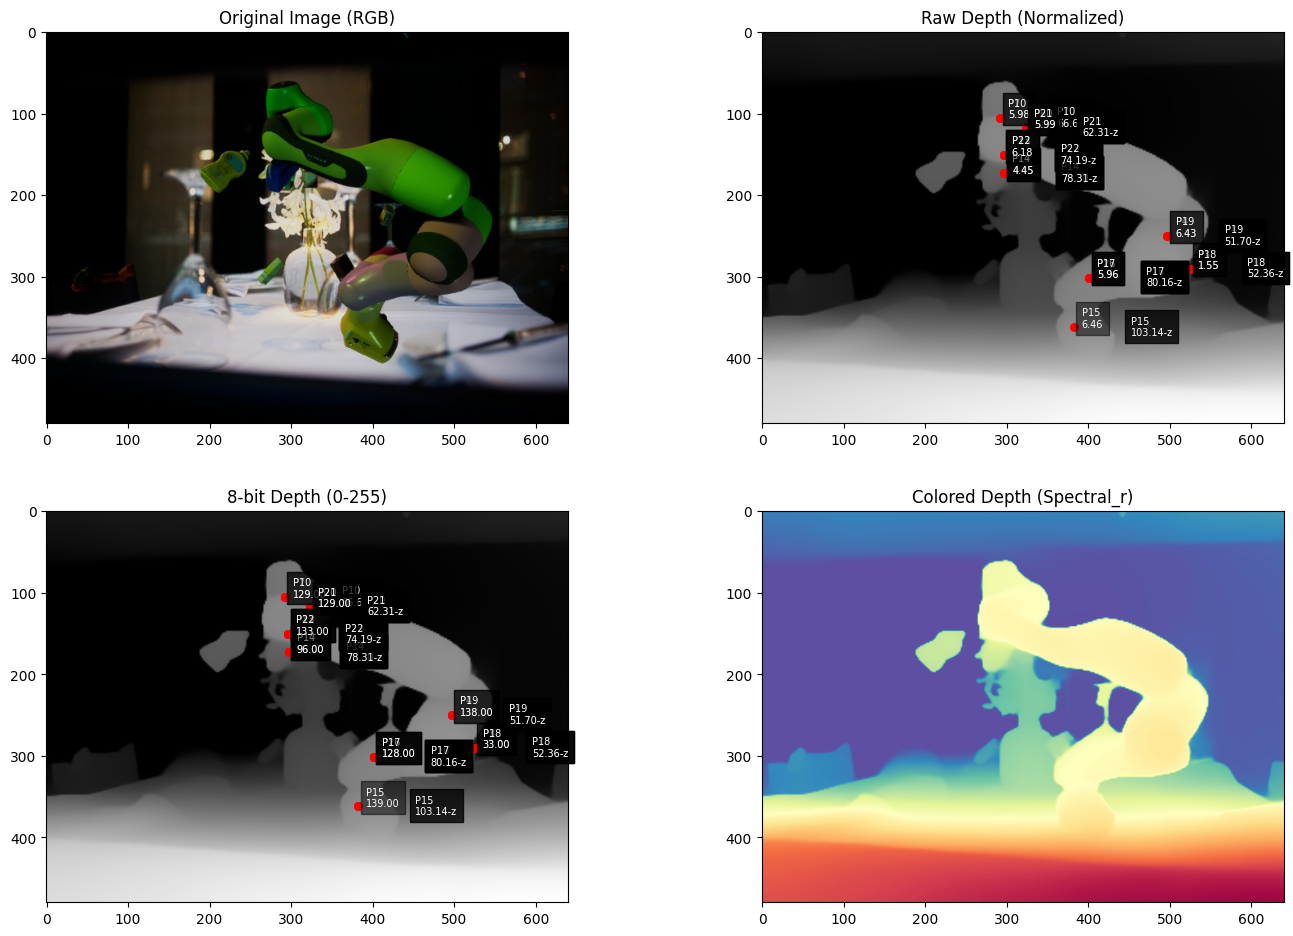

: 

In [ ]:
import os
import json
import numpy as np
from PIL import Image
import torch
import matplotlib
import matplotlib.pyplot as plt
import tempfile
from DepthAnythingV2.depth_anything_v2.dpt import DepthAnythingV2
torch.cuda.set_device(4)
JOINT_NAMES={
    'panda': ['panda_joint1', 'panda_joint2', 'panda_joint3', 'panda_joint4', 
            'panda_joint5', 'panda_joint6', 'panda_joint7', 'panda_finger_joint1'],
    'kuka': ['iiwa_joint_1', 'iiwa_joint_2', 'iiwa_joint_3', 'iiwa_joint_4', 
                'iiwa_joint_5', 'iiwa_joint_6', 'iiwa_joint_7'],
    'baxter': ['head_pan', 'right_s0', 'left_s0', 'right_s1', 'left_s1', 
               'right_e0', 'left_e0', 'right_e1', 'left_e1', 'right_w0', 
               'left_w0', 'right_w1', 'left_w1', 'right_w2', 'left_w2'],
    'owi535' :[
        'Rotation', 'Base', 'Elbow', 'Wrist'
    ]
}
# 1. 模型初始化
DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}
name = "vitb"
model = DepthAnythingV2(**model_configs[name])
model.load_state_dict(torch.load(f'models/depth_anything_v2_{name}.pth', map_location="cpu"))
model = model.to(DEVICE).eval()

# 2. 核心推理函数
def predict_depth(image, input_size = 256):
    """输入BGR格式numpy数组，返回浮点型深度图"""
    with torch.no_grad():
        # 模型内部已包含预处理（归一化/尺寸调整）
        depth = model.infer_image(image, input_size)  
    return depth

# 3. 完整处理流程（含后处理）
def process_image(image, input_size = 256):
    """输入RGB格式numpy数组，返回可视化结果"""
    # 转换BGR格式
    bgr_image = image[:, :, ::-1].copy()
    
    # 执行推理
    raw_depth = predict_depth(bgr_image, input_size)
    
    # 归一化到0-255
    normalized_depth = (raw_depth - raw_depth.min()) / (raw_depth.max() - raw_depth.min()) * 255.0
    uint8_depth = normalized_depth.astype(np.uint8)
    
    # 伪彩色映射
    cmap = matplotlib.colormaps.get_cmap('Spectral_r')
    colored_depth = (cmap(uint8_depth)[:, :, :3] * 255).astype(np.uint8)
    
    return [
        raw_depth,          # 原始深度值（float）
        uint8_depth,      # 8位灰度深度图
        colored_depth   # 伪彩色可视化结果
    ]
# path = 'assets/examples/demo01.jpg'
base_dir = './data/dream'
# choice = 'real/panda-3cam_azure'
choice = 'synthetic/panda_synth_train_dr'
file_name = '000001'
data_dir = os.path.join(base_dir, choice)
img_path = os.path.join(data_dir, file_name + '.rgb.jpg')
annotation_path = os.path.join(data_dir, file_name + '.json')


image = plt.imread(img_path)
with open(annotation_path, 'r') as f:
    annotations = json.load(f)

keypoints = annotations['objects'][0]['keypoints']
print(keypoints)
projected_points = [
    point['projected_location'] 
    for point in keypoints 
    if 'collision' not in point['name'].lower()  # 排除名称含collision的点
]
points3d = [
    point['location'] 
    for point in keypoints 
    if 'collision' not in point['name'].lower()  # 排除名称含collision的点
]
    
print(projected_points)
print(points3d)
raw, uint, color = process_image(image)
print(image.shape, raw.shape, uint.shape, color.shape)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# 显示原始图像
axs[0, 0].imshow(image)
axs[0, 0].set_title('Original Image (RGB)', fontsize=12)
# axs[0, 0].axis('off')

# 显示原始深度图（线性归一化）
raw_normalized = (raw - raw.min()) / (raw.max() - raw.min())  # 归一化到0-1
axs[0, 1].imshow(raw_normalized, cmap='gray')
axs[0, 1].set_title('Raw Depth (Normalized)', fontsize=12)
# axs[0, 1].axis('off')
for i, (x, y) in enumerate(projected_points):
    x_int, y_int = int(x), int(y)
    depth_val = raw[y_int, x_int]  # 注意坐标顺序(y,x)
    gt_depth = points3d[i][2]
    axs[0, 1].scatter(x_int, y_int, c='red', s=30)
    axs[0, 1].text(x_int+10, y_int, f'P{i}\n{depth_val:.2f}', 
                 color='white', fontsize=7, bbox=dict(facecolor='black', alpha=0.5))
    axs[0, 1].text(x_int+70, y_int+10, f'P{i}\n{gt_depth:.2f}-z', 
                 color='white', fontsize=7, bbox=dict(facecolor='black', alpha=0.8))
    
# 显示8位深度图
axs[1, 0].imshow(uint, cmap='gray')
axs[1, 0].set_title('8-bit Depth (0-255)', fontsize=12)
for i, (x, y) in enumerate(projected_points):
    x_int, y_int = int(x), int(y)
    print(y_int, x_int)
    depth_val = uint[y_int, x_int]  # 注意坐标顺序(y,x)
    gt_depth = points3d[i][2]
    axs[1, 0].scatter(x_int, y_int, c='red', s=30)
    axs[1, 0].text(x_int+10, y_int, f'P{i}\n{depth_val:.2f}', 
                 color='white', fontsize=7, bbox=dict(facecolor='black', alpha=0.5))
    axs[1, 0].text(x_int+70, y_int+10, f'P{i}\n{gt_depth:.2f}-z', 
                 color='white', fontsize=7, bbox=dict(facecolor='black', alpha=0.8))
    axs[1, 0].scatter(x_int, y_int, c='red', s=30)
    
# axs[1, 0].axis('off')

# 显示伪彩色深度图
axs[1, 1].imshow(color)
axs[1, 1].set_title('Colored Depth (Spectral_r)', fontsize=12)
# axs[1, 1].axis('off')

# 调整子图间距
plt.tight_layout(pad=3.0)
plt.show()